# FASTAPI
#### Objetivo: Saber qué es FastAPI y Uvicorn, instalar los mismos

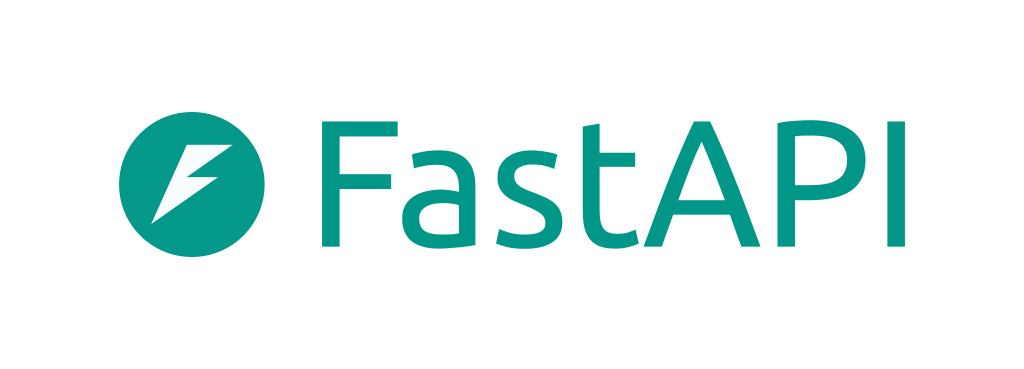

In [1]:
from PIL import Image
from IPython.display import display

imagen = Image.open("media/fastApiLogo.png")
display(imagen)


### FastAPI es un framework web moderno, rápido (de alto rendimiento), para construir APIs con Python basado en las anotaciones de tipos estándar de Python.

Las funcionalidades clave son:

- Rápido: Muy alto rendimiento, a la par con NodeJS y Go (gracias a Starlette y Pydantic). Uno de los frameworks Python más rápidos disponibles.
- Rápido de programar: Aumenta la velocidad para desarrollar funcionalidades en aproximadamente un 200% a 300%. *
- Menos bugs: Reduce en aproximadamente un 40% los errores inducidos por humanos (desarrolladores).
- Intuitivo: Gran soporte para editores. Autocompletado en todas partes. Menos tiempo depurando.
- Fácil: Diseñado para ser fácil de usar y aprender. Menos tiempo leyendo documentación.
- Corto: Minimiza la duplicación de código. Múltiples funcionalidades desde cada declaración de parámetro. Menos bugs.
- Robusto: Obtén código listo para producción. Con documentación interactiva automática.
- Basado en estándares: Basado (y completamente compatible) con los estándares abiertos para -APIs: OpenAPI (anteriormente conocido como Swagger) y JSON Schema.

### Uvicorn es un servidor web ASGI (Asynchronous Server Gateway Interface) extremadamente rápido y ligero para Python, diseñado para ejecutar aplicaciones asíncronas, siendo la opción principal para FastAPI. Basado en uvloop y httptools, ofrece un rendimiento alto al gestionar eficientemente múltiples solicitudes concurrentes y soporte para WebSockets. 
Aspectos clave de Uvicorn:
- Servidor ASGI: Es una implementación de servidor de alto rendimiento que conecta aplicaciones Python con servidores web, reemplazando la antigua especificación WSGI por una moderna y asíncrona.
- Velocidad: Utiliza uvloop (una alternativa rápida al bucle de eventos asyncio estándar) y httptools para analizar protocolos HTTP.
- Desarrollo Rápido: Cuenta con una opción --reload que reinicia el servidor automáticamente al detectar cambios en el código, ideal para desarrollo activo.
- Producción: Aunque se puede usar en desarrollo, se recomienda usarlo con gestores de procesos como gunicorn para producción para una mejor gestión de trabajadores.
- Uso: Se instala comúnmente con pip install uvicorn[standard] y se ejecuta con uvicorn main:app --reload. 
Uvicorn es, esencialmente, el motor que permite a las aplicaciones modernas de Python manejar miles de peticiones simultáneas con baja latencia. 

## 1 - Instalación

## En la terminal de VS Code (Windows):
python -m venv venv
.\venv\Scripts\activate

## (Mac/Linux):
 source venv/bin/activate

## 2 - El Código del Backend (main.py)
Crear un archivo nuevo llamado main.py. Este será el cerebro de nuestro sistema. Aquí definiremos qué datos aceptamos de las consultoras.


from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List

app = FastAPI(
    title="API de Escrutinio Provisorio",
    description="Backend para recibir telegramas de mesas testigo.",
    version="1.0.0"
)

# --- 1. MODELO DE DATOS (La validación) ---
class TelegramaMesa(BaseModel):
    mesa_id: int
    distrito: str
    partido_oficialista: int
    partido_opositor: int
    votos_nulos: int

# --- 2. BASE DE DATOS (Simulada en memoria) ---
base_datos_telegramas = []

# --- 3. ENDPOINTS (Las puertas de la API) ---

@app.get("/")
def home():
    return {"status": "Sistema de Escrutinio Online 🟢"}

@app.post("/cargar-telegrama/")
def recibir_datos(telegrama: TelegramaMesa):
    # Validación lógica: No puede haber votos negativos (aunque Pydantic ya ayuda)
    if telegrama.partido_oficialista < 0 or telegrama.partido_opositor < 0:
        raise HTTPException(status_code=400, detail="Error: Votos negativos detectados (Posible fraude)")
    
    base_datos_telegramas.append(telegrama)
    return {"mensaje": f"Mesa {telegrama.mesa_id} cargada exitosamente"}

@app.get("/resultados-boca-de-urna/")
def calcular_ganador():
    if not base_datos_telegramas:
        return {"mensaje": "Esperando datos de las mesas..."}

    # Agregación de datos (Data Science básico)
    total_oficialismo = sum(t.partido_oficialista for t in base_datos_telegramas)
    total_oposicion = sum(t.partido_opositor for t in base_datos_telegramas)
    total_general = total_oficialismo + total_oposicion

    # Evitar división por cero
    if total_general == 0:
         return {"mensaje": "Hay mesas pero sin votos válidos"}

    porcentaje_oficial = round((total_oficialismo / total_general) * 100, 2)
    porcentaje_opositor = round((total_oposicion / total_general) * 100, 2)

    return {
        "tendencia": "GANADOR PROYECTADO: " + ("OFICIALISMO" if total_oficialismo > total_oposicion else "OPOSICIÓN"),
        "datos_absolutos": {
            "oficialismo": total_oficialismo,
            "oposicion": total_oposicion
        },
        "porcentajes": {
            "oficialismo": f"{porcentaje_oficial}%",
            "oposicion": f"{porcentaje_opositor}%"
        },
        "mesas_escrutadas": len(base_datos_telegramas)
    }

## 3: Encender el Motor
Volver a la terminal. Vamos a despertar a nuestro servidor para que empiece a escuchar peticiones

uvicorn main:app --reload

Posteriormente abrir el navegador en: http://127.0.0.1:8000/docs
Verán la documentación automática (Swagger UI). Pueden probar los botones "Try it out" y cargar datos manualmente.

## 4: El Consumidor (Jupyter Notebook dentro de VS Code)

Crear un archivo dashboard.ipynb en la misma carpeta.
En este notebook, consumirán la API que está corriendo en la terminal.

### Celda 1: Simulación de Carga (Fiscales enviando datos)

In [ ]:
import requests
import random
import time

URL = "http://127.0.0.1:8000"

# Simulamos que llegan datos de 10 mesas distintas
distritos = ["CABA", "PBA", "CORDOBA", "MENDOZA"]

print("📡 Iniciando transmisión de datos de mesas testigo...")

for i in range(1, 11):
    datos_simulados = {
        "mesa_id": 1000 + i,
        "distrito": random.choice(distritos),
        "partido_oficialista": random.randint(50, 150), # Votos aleatorios
        "partido_opositor": random.randint(40, 160),
        "votos_nulos": random.randint(0, 5)
    }
    
    # Enviamos el dato a NUESTRA API
    requests.post(f"{URL}/cargar-telegrama/", json=datos_simulados)
    print(f"✅ Mesa {1000+i} procesada.")
    time.sleep(0.5) # Pausa dramática para simular tiempo real

### Celda 2: El Tablero de Control (Visualización)

In [ ]:
import matplotlib.pyplot as plt

# 1. Consultamos al "Oráculo" (Nuestra API)
respuesta = requests.get(f"{URL}/resultados-boca-de-urna/")
data = respuesta.json()

print("📢 FLASH INFORMATIVO:", data['tendencia'])

# 2. Graficamos
if "datos_absolutos" in data:
    votos = [data['datos_absolutos']['oficialismo'], data['datos_absolutos']['oposicion']]
    labels = ['Oficialismo', 'Oposición']
    colores = ['#1f77b4', '#ff7f0e'] # Azul y Naranja

    plt.figure(figsize=(6, 6))
    plt.pie(votos, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90)
    plt.title(f"Resultados Parciales (Mesas: {data['mesas_escrutadas']})")
    plt.show()
else:
    print("Esperando datos...")